<a href="https://colab.research.google.com/github/LucioFassarella/Qiskit/blob/main/Qiskit_Separador_de_Feixe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color="red"><b>Computação Quântica</b></font>

<center><img align = "center" src="https://drive.google.com/uc?export=view&id=1usXrPscUXzfQF5wNtkvuVGARuuhcgyw-" alt="grafo" width="500"></center>

<center>"You never understand things. You just get used to them." (John von Neumann)</center>

---

<font color = "orange">**Qiskit**:</font>
*   [Python's Instalation](https://pypi.org/project/qiskit/)
*   [IBM Quantum cloud](https://quantum.cloud.ibm.com/)
    *   [Qiskit connect](https://cloud.ibm.com/docs/quantum-computing?topic=quantum-computing-get-started) (IBM Runtime Service)
       *   [Getting Started](https://cloud.ibm.com/docs/quantum-computing?topic=quantum-computing-get-started)
*   [Qiskit](https://docs.quantum.ibm.com/api/qiskit)
    *   [Qiskit Quantum Circuit](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.QuantumCircuit)
    *   [Qiskit Circuit Library](https://docs.quantum.ibm.com/api/qiskit/circuit_library)
    *   [Qiskit Gates Tutorial](https://github.com/Qiskit/qiskit-tutorials/blob/master/tutorials/circuits/3_summary_of_quantum_operations.ipynb)
    *   [List of Quantum Logic Gates](https://en.wikipedia.org/wiki/List_of_quantum_logic_gates)

[<font color="orange">**Execution modes**</font>](https://quantum.cloud.ibm.com/docs/en/guides/execution-modes)

*	[Choose the execution mode](https://quantum.cloud.ibm.com/docs/en/guides/choose-execution-mode)
*   [Single Job](https://quantum.cloud.ibm.com/docs/en/guides/primitives-examples#estimator-examples)
*	[Batch mode](https://quantum.cloud.ibm.com/docs/en/guides/run-jobs-batch)
*	[Section mode](https://quantum.cloud.ibm.com/docs/en/guides/run-jobs-session)
*	[Primitives examples](https://quantum.cloud.ibm.com/docs/en/guides/primitives-examples)


[<font color="green">**Local simulators**</font>](https://quantum.cloud.ibm.com/docs/en/migration-guides/local-simulators)

---

⏬

## QISKIT: Carregamento

In [1]:
!pip install qiskit -U
!pip install qiskit_aer -U
!pip install qiskit-ibm-runtime -U

!pip install matplotlib
!pip install pylatexenc*
import qiskit
qiskit.__version__

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 90.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 378.6/378.6 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 6.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 6.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=7d811fd6c2d937e76e39f996f134b5446486a47c172addcd07f08271bcc5ae07
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178b

'2.3.0'

In [3]:
# Qiskit: métodos básicos

from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister

from qiskit import transpile

from qiskit.visualization import plot_histogram, array_to_latex, plot_state_city

# AER Simulator

In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# 1. Create the Quantum Circuit (Bell State)
qc = QuantumCircuit(2, 2)
qc.h(0)           # Hadamard gate on qubit 0
qc.cx(0, 1)       # CNOT gate (control: 0, target: 1)
qc.measure([0, 1], [0, 1]) # Measure both qubits

# 2. Set up the Simulator
simulator = AerSimulator()

# 3. Run the Circuit
job = simulator.run(qc, shots=1000)
result = job.result()

# 4. Get and Print Results
counts = result.get_counts(qc)
print("\nTotal counts:", counts)

# 5. Visualize Results
plot_histogram(counts)
plt.show()


Total counts: {'00': 546, '11': 454}


# Separador de Feixe com Detector de Caminho

<b>Como modelar o sistema constituído por um separador de feixe combinado com uma transformação que interage somente com uma parte do feixe separado?</b>

<center><img align = "center" src="https://drive.google.com/uc?export=view&id=1LaKBXspAhXLbdnrGgDWQuSRmGki-0OVl" alt="grafo" width="500"></center>

<center>Separador de Feixe com transformação em somente parte do
estado separado.</center>

A situação é análoga ao experimento da <i>Dupla Fenda com detector de caminho</i>...

⬇

<b> Modelagem por circuito quântico</b>


Podemos modelar a situação usando dois qubits: um para representar o feixe (qubit principal) e outro (qubit auxiliar) para distinguir a <i>transmissão/deflexão</i>. Denotando o qubit principal por $q_0$, o qubit auxiliar por $q_1$ e considerando que a transformação que atua somente no feixe transmitido é dada por um operador $U$, o circuito é dado pela composição dos seguintes operadores:

*   $R_{y;0}(s)$: rotação do qubit $q_0$ representando a separação de feixes com índices de transmissão/reflexão dependentes do parâmetro $s \in \left\lbrack 0, 2\pi \right)$;
*   $CX_{0\rightarrow 1}^{0}$: CNOT com qubit de controle $q_0$, qubit alvo $q_1$ e valor de ativação $q_0 = 0$;
*   $CU_{1\rightarrow 1}^{1}$: CNOT com qubit de controle $q_1$, qubit alvo $q_0$ e valor de ativação $q_1 = 1$.


<font color = "gray">Observação: $U(\theta, \phi, \lambda)$ é a porta geral de 1 qubit. Essa porta controlada leva mais um parâmetro, colocado $0$ no circuito abaixo. Para detalhes, veja: [https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.CUGate](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.CUGate).</font>

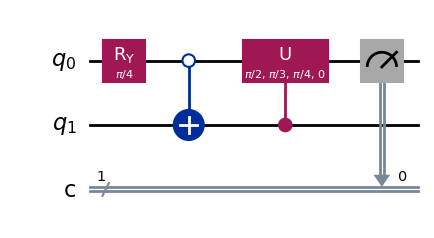

In [10]:
# Pacotes

import numpy as np

# Parâmetros

s = np.pi/4

theta = np.pi/2
phi = np.pi/3
lambd = np.pi/4

# Circuito

qc = QuantumCircuit(2,1)
qc.ry(s,0)
qc.cx(0,1, ctrl_state = '0')
qc.cu(theta, phi, lambd, 0, 1, 0, ctrl_state = '1')
qc.measure(0,0)
qc.draw('mpl')